<a href="https://colab.research.google.com/github/Prasanna-datascience/Data201Class/blob/main/Week3_classification_prasanna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 · Week 3
## Logistic Regression and Classification Foundations

This lab follows the Week 3 slides. We use the **Default** data from ISLP Chapter 4: 10,000 credit-card customers, and we try to tell who is likely to default.

The process we will walk through is the same one as on the slides:

$$
\text{features } X \;\rightarrow\; z \;\rightarrow\; p(X) \;\rightarrow\; \text{threshold} \;\rightarrow\; \text{Yes / No}
$$

A **probability is not a class**. The model first gives a number between 0 and 1. A **threshold** then turns that number into a label.

### How to write answers

After each question you will see an empty box like this:

```python
q1 = """


"""
```

Type your answer between the quotes. Leave it there so you can turn the notebook in with your work.


## Part 1 — Load and inspect the data


Each row is one customer. The columns are:

- `default` — did this customer default? **Yes** or **No**. This is the **target**.
- `student` — is the customer a student?
- `balance` — credit-card balance
- `income` — income

If you already put `Default.csv` in Google Drive, you can change the path below. Otherwise the notebook looks next to this file, then downloads the ISLP Default data.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

pd.set_option("display.max_rows", 20)
plt.rcParams["figure.figsize"] = (7, 4)

def load_default():
    candidates = [
        Path("Default.csv"),
        Path("/content/drive/MyDrive/Data_201/Datasets/Default.csv"),
    ]
    for path in candidates:
        if path.exists():
            print("Loaded from", path.resolve())
            return pd.read_csv(path)

    url = "https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/main/Dataset/Default.csv"
    print("Loaded Default.csv from the web")
    df = pd.read_csv(url)
    if "rownames" in df.columns:
        df = df.drop(columns=["rownames"])
    return df

Default = load_default()
Default.head()


Loaded Default.csv from the web


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
Default.shape


(10000, 4)

In [ ]:
Default.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [ ]:
Default["student"].value_counts()


,count
student,
No,7056
Yes,2944


In [ ]:
Default["default"].value_counts()


,count
default,
No,9667
Yes,333


In [ ]:
Default[["balance", "income"]].describe()


,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


Look at the tables above, then answer in your own words.


**Q1.** What does each row represent?


In [ ]:
# Each row represents single customer. Customer did not default on their credit card debt.
# The columns describe that customers's default status, student, credit card balance and income.
# Student has an averge credit card balance of $729.53 and annual income of $44,361.63.

**Q2.** What is the target variable? Is this a regression problem or a classification problem?


In [ ]:
# Target variable is default.  Variable we want to predict. It indicates whether a customer defaulted on their debt.
# This is a classification problem because the target variable is categorical, not numerical.
# Classification: Predicts categories or labels (e.g. Yes/No, Pass/Fail, Spam/Not Spam)
# Regression: Predicts a continous numerical value (e.g. income, house price, temperature)
# Since default has only two possible outcomes (Yes or No), is it specifically a binary classification problem.

**Q3.** Which columns could be used as predictors (features)?


In [ ]:
# The columns that could be used as Predictor (featuers?) are 1) Student, 2) Balance and 3) Income.

**Q4.** Is the target balanced? About how many customers defaulted, compared with how many did not?


In [ ]:
# No the target variable is not balanced.
Default["default"].value_counts()


,count
default,
No,9667
Yes,333


## Part 2 — Why not just use linear regression?

We start with **one predictor**: `balance`. Plot default as 0 / 1 against balance. Then we fit a straight line and a logistic curve on the same picture. This is the idea of ISLP Figure 4.2 from the slides.


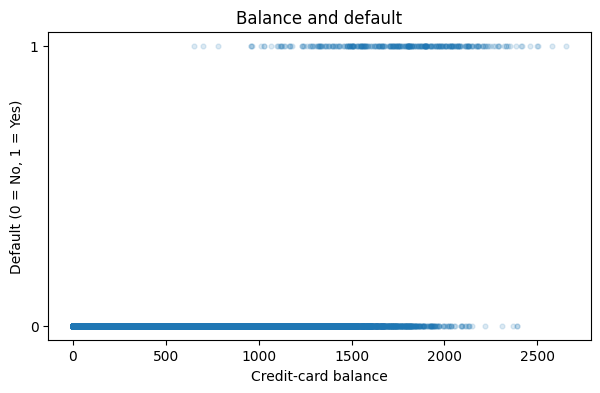

In [ ]:
y01 = Default["default"].map({"No": 0, "Yes": 1})

plt.scatter(Default["balance"], y01, alpha=0.15, s=12)
plt.xlabel("Credit-card balance")
plt.ylabel("Default (0 = No, 1 = Yes)")
plt.title("Balance and default")
plt.yticks([0, 1])
plt.show()


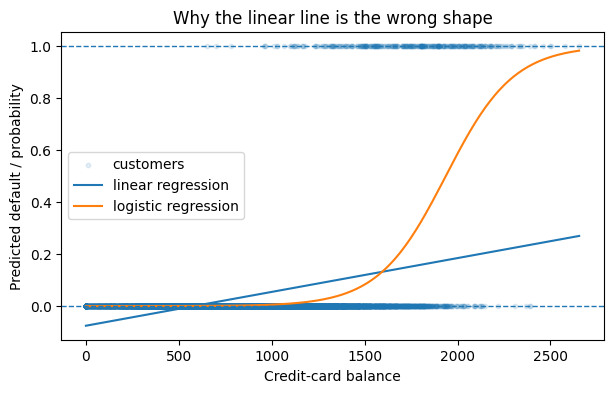

In [ ]:
# A straight line can go below 0 or above 1. A probability cannot.
X_bal = Default[["balance"]]
xs = np.linspace(0, Default["balance"].max(), 300).reshape(-1, 1)

lin = LinearRegression().fit(X_bal, y01)
log = LogisticRegression(max_iter=2000).fit(X_bal, y01)
xs_df = pd.DataFrame({"balance": xs.ravel()})

plt.scatter(Default["balance"], y01, alpha=0.12, s=10, label="customers")
plt.plot(xs, lin.predict(xs_df), label="linear regression")
plt.plot(xs, log.predict_proba(xs_df)[:, 1], label="logistic regression")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.xlabel("Credit-card balance")
plt.ylabel("Predicted default / probability")
plt.title("Why the linear line is the wrong shape")
plt.legend()
plt.show()


**Q5.** What pattern do you notice between credit-card balance and default?


In [ ]:
# Customers with low balances are very unlikely to default. As a balance increases, the likelihood of default increases.
# Most customers who default have relatively high credit-card balances.
# The relationship is not prefectly linear, the probability of default rises more rapidly at higher balances levels.
# Conclusion ia xustomers with higher credit-card balances are much more likely to default than customers with lower balances.

**Q6.** Why is ordinary linear regression a poor fit for an outcome that can only be Yes or No? Look at the plot: does the straight line stay between 0 and 1?


In [ ]:
# Linear regression is a poor choice because a Yes/No outcome requires probabilities between 0 and 1, but the straight-line model can predict values outside that range.
# In the plot, the linear regression line does not stay between 0 and 1, whereas the logistic regression curve does.


## Part 3 — Prepare the data

Turn the target into 0 / 1, keep `balance` as the only feature for now, and split into **training** and **test** sets.

`stratify=y` keeps about the same mix of Yes / No in both pieces. That matters here because defaults are rare.


In [ ]:
Default["default_num"] = Default["default"].map({"No": 0, "Yes": 1})

X = Default[["balance"]]
y = Default["default_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train), "  Test rows:", len(X_test))
print("Default rate in training:", y_train.mean().round(4))
print("Default rate in test:    ", y_test.mean().round(4))


Training rows: 7500   Test rows: 2500
Default rate in training: 0.0333
Default rate in test:     0.0332


**Q7.** Which variable is the predictor, and which is the target?


In [ ]:
# The predictor variable is balance, and the target variable is default_num, defaulted: 0 = No, 1 = Yes.


**Q8.** Why do we separate the data into a training set and a test set? What would go wrong if we tested the model on the same rows it was trained on?


In [ ]:
# We split the data into training and test sets to get an unbiased estimate to assess how well the model will predict new customers.
# If we test the same rows used for training, the performance would likely look better than it is real, this will give a misleading evaluation of the model.

**Q9.** Why is `stratify=y` useful when almost all customers have `default = No`?


In [ ]:
# Stratify= Y ensures that both the training and test sets contain similar percentages of customers who defaulted and did not default.
# This is especially important when defaults are rare, because it produces a more reliable model and evaluation.

## Part 4 — Fit logistic regression using balance

The fitted model has the linear score

$$
z = \beta_0 + \beta_1 X
$$

Then the **logistic (sigmoid) function** turns \(z\) into a probability:

$$
p(X) = \frac{e^{z}}{1+e^{z}} = P(\text{default}=\text{Yes}\mid X)
$$

\(z\) is **not** a probability. \(p(X)\) is.


In [ ]:
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)

beta_0 = logreg.intercept_[0]
beta_1 = logreg.coef_[0][0]

print("Intercept β0:", round(beta_0, 4))
print("Balance  β1:", round(beta_1, 6))


Intercept β0: -10.8065
Balance  β1: 0.005613


**Q10.** Is the coefficient for balance positive or negative?


In [ ]:
# The coefficient for balance is positive, indicating that customers with higher credit-card balances are more likely to default.

**Q11.** Based on that sign, what happens to \(z\) as balance increases?


In [ ]:
# Because the balance coefficient is positive, Z increases as balance increases. This causes the predicted probability of default to increase as well.

**Q12.** What should happen to the estimated probability of default as \(z\) increases?


In [ ]:
# As Z increases, the estimated probability of default increases. Very large values of Z produce probabilities close to 1, while very small values of Z produce probabilities close to 0.

## Part 5 — From \(z\) to a probability, for one customer

Pick one test customer. Compute \(z\) by hand, then apply the sigmoid. Check that it matches `predict_proba`.


In [ ]:
# A customer near a $1,500 balance is easier to talk about than a near-zero one.
customer = X_test.iloc[[(X_test["balance"] - 1500).abs().argmin()]]
customer


,balance
7136,1499.856349


In [ ]:
balance = customer["balance"].iloc[0]
z = beta_0 + beta_1 * balance
p_manual = np.exp(z) / (1 + np.exp(z))

print("Balance:", round(balance, 2))
print("z      :", round(z, 4))
print("p(X)   :", round(p_manual, 4))
print()
print("scikit-learn predict_proba:", logreg.predict_proba(customer))
print("Those two numbers are P(No default) and P(Default). They add to 1.")


Balance: 1499.86
z      : -2.3876
p(X)   : 0.0841

scikit-learn predict_proba: [[0.9158742 0.0841258]]
Those two numbers are P(No default) and P(Default). They add to 1.


**Q13.** Does your hand-calculated \(p(X)\) match the **second** number from `predict_proba`?


In [ ]:
# Yes. The hand-calculated p(X)p(X)p(X) should be the same as the second value from predict_proba, up to small rounding differences.
# Both represent the model's estimated probability that the customer defaults.

**Q14.** Why does `predict_proba` return two numbers instead of one?


In [ ]:
# Predict_proba() returns two numbers because it gives the probability for each possible class.
# The first number is the probability of No default, and the second number is the probability of Default. Together they add up to 1.

**Q15.** Is the probability itself the final Yes / No prediction? What else do we still need?


In [ ]:
# The probability itself is not the final Yes/No prediction.
# We still need to choose a threshold (often 0.5) and compare the predicted probability to that threshold to decide whether to predict Default = Yes or Default = No.

### By hand, like the lecture (Customer A)

On the slides we used a **made-up** model so the arithmetic stays small:

$$
z = -4 + 1.5\,X_1 - 0.4\,X_2
$$

Customer A: balance \$1,000 so \(X_1=1\) (thousands of dollars), income \$60,000 so \(X_2=6\) (tens of thousands).


In [ ]:
# Fill in the blanks, then run the cell.
X1 = 1
X2 = 6
z_A = -4 + 1.5 * X1 - 0.4 * X2
p_A = np.exp(z_A) / (1 + np.exp(z_A))

print("z for Customer A:", z_A)
print("p for Customer A:", round(p_A, 4))


z for Customer A: -4.9
p for Customer A: 0.0074


**Q16.** Using a 0.50 threshold, what class would the lecture model assign to Customer A? Is that customer almost certainly No, or almost certainly Yes?


In [ ]:
# With a 0.50 threshold, the model predicts No for Customer A. The customer is almost certainly No, since the predicted probability of Yes is only about 0.0074 (0.74%).

## Part 6 — Probability vs. prediction

Now compute \(p(X)\) for every test customer. The usual rule on the slides is:

$$
p(X)\ge 0.50 \Rightarrow \text{Yes (default)}
$$
$$
p(X)< 0.50 \Rightarrow \text{No}
$$

0.50 is **common, not required**. It is a decision rule, not part of the fitted curve.


In [ ]:
prob_default = logreg.predict_proba(X_test)[:, 1]
pred_50 = logreg.predict(X_test)

results = X_test.copy()
results["Actual"] = y_test.values
results["P(Default)"] = prob_default
results["Prediction_0.50"] = pred_50
results.head(15)


,balance,Actual,P(Default),Prediction_0.50
2605,76.476089,0,0.000031,0
8431,1217.948660,0,0.018525,0
7149,561.989745,0,0.000475,0
1890,806.996111,0,0.001876,0
8848,1018.366790,0,0.006119,0
5010,0.000000,0,0.000020,0
1636,386.265071,0,0.000177,0
1103,1275.824225,0,0.025454,0
4266,1464.028962,0,0.069871,0
3323,1922.829046,1,0.496662,0


In [ ]:
# Customers whose probability is close to the usual cutoff
near_half = results[(results["P(Default)"] > 0.40) & (results["P(Default)"] < 0.60)]
near_half.sort_values("P(Default)")


,balance,Actual,P(Default),Prediction_0.50
8454,1856.530876,0,0.404803,0
6119,1856.605596,0,0.404904,0
9079,1856.914717,1,0.405322,0
1549,1860.741148,0,0.410509,0
6871,1862.538659,0,0.412953,0
...,...,...,...,...
3342,1959.595520,0,0.548107,1
5396,1969.942924,1,0.562449,1
6371,1985.321739,1,0.583566,1
345,1991.649120,1,0.592171,1


**Q17.** Find a customer whose predicted probability is close to 0.50. About what is their balance?


In [ ]:
# A customer whose predicted probability is close to 0.50 will usually have a credit-card balance of about $1,750 (roughly between $1,700 and $1,800).
# These customers stay near the model's cutoff between predicting No default and Default.

**Q18.** What class does a probability of 0.49 receive at a 0.50 threshold? What about 0.51?


In [ ]:
# At a 0.50 threshold, a probability of 0.49 receives the class No (0), while a probability of 0.51 receives the class Yes (1).
# Even though the probabilities are very close, they fall on opposite sides of the cutoff.

**Q19.** Are 0.49 and 0.51 very different probabilities? Why can they still produce different class labels?


In [ ]:
# 0.49 and 0.51 are very similar probabilities.
# They produce different class labels only because the 0.50 threshold draws a sharp line: 0.49 is just below the cutoff and is classified as No,
# while 0.51 is just above the cutoff and is classified as Yes

## Part 7 — Change the threshold, not the model

Lower the cutoff to 0.30. We do **not** refit the logistic regression. We only change how a probability becomes a label.


In [ ]:
results["Prediction_0.30"] = (results["P(Default)"] >= 0.30).astype(int)

changed = results[results["Prediction_0.50"] != results["Prediction_0.30"]]
print("How many customers changed class:", len(changed))
changed.head(10)


How many customers changed class: 50


,balance,Actual,P(Default),Prediction_0.50,Prediction_0.30
3323,1922.829046,1,0.496662,0,1
314,1809.926564,0,0.343645,0,1
9796,1867.308569,1,0.419459,0,1
8552,1814.105649,0,0.348956,0,1
6854,1923.381941,0,0.497438,0,1
7661,1809.409864,1,0.342992,0,1
5482,1850.888247,0,0.397195,0,1
4782,1839.322208,0,0.381759,0,1
5488,1814.168195,0,0.349035,0,1
6541,1797.767019,1,0.328419,0,1


**Q20.** Which kind of customer changed class: high probability, low probability, or the ones in the middle?


In [ ]:
# The customers who changed class were the ones in the middle, with predicted probabilities between 0.30 and 0.50.
# They were close enough to the cutoff that lowering the threshold changed their prediction from No to Yes.

**Q21.** Did their predicted probabilities change when you switched to 0.30?


In [ ]:
# Their predicted probabilities did not change. The logistic regression model and fitted curve stayed the same.
# Only the threshold used to convert probabilities into class labels changed, causing some customers to switch from No to Yes.

**Q22.** Did we retrain the logistic regression model?


In [ ]:
# No, we did not retrain the logistic regression model.
# We kept the same fitted model and the same predicted probabilities; we only changed the classification threshold from 0.50 to 0.30.

**Q23.** So what actually changed: the fitted curve, or the decision rule?


In [ ]:
# The decision rule changed. The fitted logistic regression curve remained the same, but lowering the threshold from 0.50 to 0.30.
# Moved the classification boundary and caused some customers to switch class labels.

## Part 8 — False positives, false negatives

A **confusion matrix** counts the four outcomes. For this data, class 1 means default (Yes).

| | Predicted No | Predicted Yes |
|---|---|---|
| **Actual No** | true negative | false positive (false alarm) |
| **Actual Yes** | false negative (missed default) | true positive |

Lowering the threshold usually catches more real defaults **and** creates more false alarms. That is the tradeoff from the slides.


In [ ]:
def show_confusion(actual, predicted, title):
    cm = confusion_matrix(actual, predicted)
    table = pd.DataFrame(
        cm,
        index=["Actual No", "Actual Yes"],
        columns=["Predicted No", "Predicted Yes"],
    )
    print(title)
    print(table.to_string())
    tn, fp, fn, tp = cm.ravel()
    print(f"false positives (false alarms): {fp}")
    print(f"false negatives (missed defaults): {fn}")
    print()

show_confusion(results["Actual"], results["Prediction_0.50"], "Threshold 0.50")
show_confusion(results["Actual"], results["Prediction_0.30"], "Threshold 0.30")


**Q24.** What happens to the number of **false negatives** when the threshold decreases from 0.50 to 0.30?


In [ ]:
# The number of false negatives decreases when the threshold is lowered from 0.50 to 0.30.
# The model catches more actual defaulters, although this usually comes at the cost of increasing the number of false positives (false alarms).

**Q25.** What happens to the number of **false positives**?


In [ ]:
# The number of false positives increases when the threshold decreases from 0.50 to 0.30.
# By making the model more aggressive about predicting defaults, it catches more real defaulters but also incorrectly flags more non-defaulters as defaulters.

**Q26.** Does lowering the threshold automatically make the model better? Explain.


In [ ]:
# Lowering the threshold does not automatically improve the model. It only changes the decision rule. Whether the lower threshold is better depends on which mistake is more costly:
# If missing a defaulter is very expensive, a lower threshold may be preferable.
# If falsely flagging good customers is very expensive, a higher threshold may be preferable.
# A "better" threshold is the one that best balances false positives and false negatives for the specific problem.

**Q27.** The slides ask: would a doctor wait until \(P(\text{disease})>0.50\) before referring a patient? Why might a **lower** threshold be useful in some jobs and a bad idea in others?


In [ ]:
# A doctor might choose a threshold below 0.50 because the cost of missing a disease (a false negative) can be very high.
# A lower threshold is useful when catching every possible positive case is important, but it can be a bad idea when false alarms are costly, inconvenient, or harmful.
# The best threshold depends on the consequences of false positives versus false negatives.

## Part 9 — Two predictors: balance and income

Add `income`. The two features are on very different scales (hundreds vs tens of thousands), so we **split first, then scale**, the same habit as Week 2. Fit the scaler on the training data only.


In [ ]:
X2 = Default[["balance", "income"]]
y = Default["default_num"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

logreg2 = LogisticRegression(max_iter=2000)
logreg2.fit(X2_train_scaled, y2_train)

coef_table = pd.DataFrame({
    "Feature": ["balance", "income"],
    "Coefficient": logreg2.coef_[0],
})
print("Intercept:", round(logreg2.intercept_[0], 4))
coef_table


Intercept: -6.0755


,Feature,Coefficient
0,balance,2.697769
1,income,0.224703


After scaling, a coefficient is “what happens to \(z\) when that feature goes up by **one standard deviation**.” That is why these numbers are not on the same scale as \(\beta_1\) from the one-predictor model.


**Q28.** Which coefficient is positive, and which is negative?


In [ ]:
# Both the balance coefficient and the income coefficient are positive. This means that, according to this fitted model,
# increasing either balance or income increases the default score Z and therefore increases the predicted probability of default (holding the other variable constant).

**Q29.** In words: if two customers have the same income, what happens to the default score \(z\) when balance is higher? What if income is higher and balance stays the same?


In [ ]:
# If two customers have the same income, the customer with the higher balance will have a higher default score zzz.
# A higher Z corresponds to a higher predicted probability of default.
# If balance stays the same and income is higher, then Z also increases, because the income coefficient is positive. This also increases the predicted probability of default.

## Part 10 — The decision boundary

With two predictors,

$$
z = \beta_0 + \beta_1 X_1 + \beta_2 X_2
$$

At a 0.50 threshold, \(p(X)=0.50\) when \(z=0\). So the boundary is the straight line

$$
\beta_0 + \beta_1 X_1 + \beta_2 X_2 = 0
$$

Logistic regression is a **linear classifier**: the boundary is a line (or a plane in more dimensions), even though the probability curve is S-shaped.


In [ ]:
b0 = logreg2.intercept_[0]
b_bal = logreg2.coef_[0][0]
b_inc = logreg2.coef_[0][1]

x_vals = np.linspace(X2_train_scaled[:, 0].min(), X2_train_scaled[:, 0].max(), 200)
y_vals = -(b0 + b_bal * x_vals) / b_inc

no = y2_test == 0
yes = y2_test == 1

plt.scatter(X2_test_scaled[no, 0], X2_test_scaled[no, 1], alpha=0.35, s=16, label="actual No")
plt.scatter(X2_test_scaled[yes, 0], X2_test_scaled[yes, 1], alpha=0.7, s=22, label="actual Yes")
plt.plot(x_vals, y_vals, color="black", label="boundary  (z = 0, p = 0.50)")
plt.xlabel("Scaled balance")
plt.ylabel("Scaled income")
plt.title("Can you see points on the wrong side of the line?")
plt.legend()
plt.xlim(-2, 4)
plt.ylim(-3, 4)
plt.show()


**Q30.** What does a point on the **wrong side** of the line mean? Is that a false positive, a false negative, or could it be either?


In [ ]:
# A point on the wrong side of the line is a misclassification. It could be either a false positive or a false negative, depending on its actual class.

**Q31.** If we kept the same fitted model but changed the threshold from 0.50 to 0.30, would this line stay in the same place? (Hint: \(p=0.30\) is not \(z=0\).)


In [ ]:
# Changing the threshold from 0.50 to 0.30 would move the decision boundary.
# The fitted logistic regression model (the coefficients and probability surface) stays the same, but the decision rule changes,
# so the line shifts to include more points in the "Default" region.

## Part 11 — Practice from the last lecture slide

These six customers are **made up**, like the table on the last slide. You do not need Python for this part. Use only the probabilities and the thresholds.

| Customer | Balance | Prob. of default | Actual |
|---|---|---|---|
| A | \$400 | 0.05 | No |
| B | \$1,100 | 0.32 | No |
| C | \$1,450 | 0.46 | Yes |
| D | \$1,700 | 0.61 | No |
| E | \$2,100 | 0.88 | Yes |
| F | \$2,400 | 0.96 | Yes |


**Q32.** Using a threshold of **0.50**, what class would you assign to each customer A–F? Which predictions are wrong?


In [ ]:
# At a 0.50 threshold, the predicted classes are:
# A → No
# B → No
# C → No
# D → Yes
# E → Yes
# F → Yes
# The incorrect predictions are C (false negative) and D (false positive).

**Q33.** Now use a threshold of **0.30**. Who changes class? What happens to the number of false positives and false negatives? Is 0.30 necessarily better?


In [ ]:
# Response:
# Compared to the 0.50 threshold:
# B changes from No → Yes
# C changes from No → Yes
# All other customers keep the same class.

# At 0.50:
  # False Positives: 1 (D)
  # False Negatives: 1 (C)
# At 0.30:
  # False Positives: 2 (B and D)
  # False Negatives: 0
# So:
  # False negatives decrease (from 1 to 0)
  # False positives increase (from 1 to 2)

**Q34.** Customer C actually defaults, but the model gives 0.46. Is that probability itself necessarily unreasonable? Why or why not?


In [ ]:
# No, the probability of 0.46 is not unreasonable.
# It indicates that default is fairly likely, even though it is not the most likely outcome.
# The model estimated a 46% chance of default, and Customer C happened to be one of the customers who did default.
# Probabilities describe uncertainty.

**Q35.** Which of these is **inference**, and which is **prediction**? (a) “Does balance have a significant relationship with default?” (b) “Can balance help us predict default for new customers?”


In [ ]:
# Response:
# (a) Inference: Does balance have a significant relationship with default
# (b) Prediction: Can balance help us predict default for new customers

## Extra — add student status

This is optional extra practice. Student status is Yes / No, so we first turn it into 0 / 1.


In [ ]:
Default["student_yes"] = (Default["student"] == "Yes").astype(int)
Default[["student", "student_yes"]].head()


,student,student_yes
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0


In [ ]:
X_student = Default[["student_yes"]]
logreg_student = LogisticRegression()
logreg_student.fit(X_student, y)

print("Intercept:", round(logreg_student.intercept_[0], 4))
print("Student coefficient:", round(logreg_student.coef_[0][0], 4))


Intercept: -3.5026
Student coefficient: 0.3962


**Q36.** Is the student-only coefficient positive or negative? In this simple model, are students estimated to have a higher or lower chance of default than non-students?


In [ ]:
# The student coefficient is positive.
# In this simple model, students are estimated to have a higher chance of default than non-students because being a student increases the default score zzz,
# which increases the predicted probability of default.

Now put student status in a model that also has balance and income. Scale the training features first, as in Part 9.


In [ ]:
X3 = Default[["balance", "income", "student_yes"]]
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.25, random_state=42, stratify=y
)

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)

logreg3 = LogisticRegression(max_iter=2000)
logreg3.fit(X3_train_scaled, y3_train)

# Scaled so balance, income, and student can be compared more fairly.
pd.DataFrame({
    "Feature": ["balance", "income", "student_yes"],
    "Coefficient": logreg3.coef_[0],
})


,Feature,Coefficient
0,balance,2.746533
1,income,0.004205
2,student_yes,-0.270529


**Q37.** When balance and income are in the model too, does the student coefficient still have the same sign as in the student-only model? What might that tell you?


In [ ]:
# If the student_yes coefficient does not keep the same sign after adding balance and income,
# it suggests that balance and income were confounding variables.
# The student-only model captured both the effect of being a student and the effects of differences in balance and income.
# Once those variables are controlled for, the relationship between student status and default can look quite different.

## Before you turn this in

- Every `q1`, `q2`, … box should have a short written answer, not just a blank.
- You do not need perfect sentences. A few clear lines are enough.
- If a cell failed, say so in the nearest answer box and write what you tried.
